# Perceptron on the Iris Dataset

In this notebook I will test the Perceptron model implemented in the `ml_from_scratch` folder of this project. I will do so on the iris dataset imported from scikit. First I will import some libraries and code that I will need to do this

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ml_from_scratch.supervised.perceptron import Perceptron
from sklearn.datasets import load_iris

Matplotlib is building the font cache; this may take a moment.


Now that we have imported the iris dataset and the other necessary libraries, we must format the data such that it is able to be learned by the Perceptron

In [5]:
data = load_iris()

# Because our simple Perceptron model can only sort data into two classes, we must cut off one of the classes which is done below.

mask = data.target < 2

# Additionally, for easier vizualisation, we will only look at two features

X = data.data[mask][:, :2]      
y = data.target[mask]        
y = np.where(y == 0, -1, 1) 

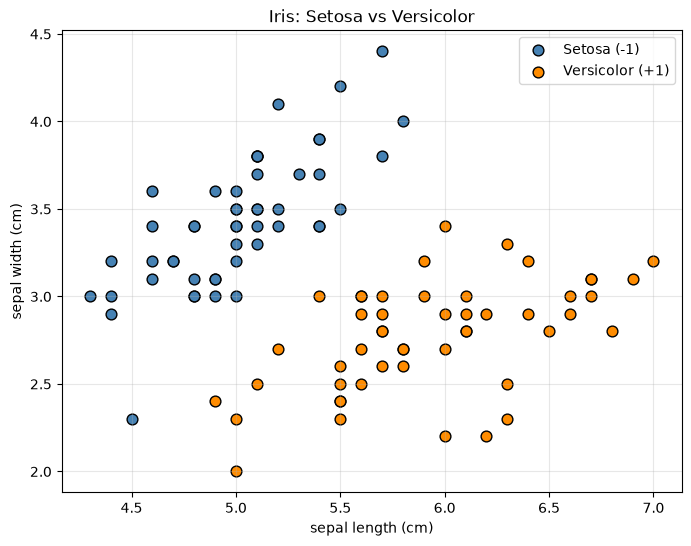

In [ ]:
plt.figure(figsize=(8, 6))

# Plotting each class of flower on a scatterplot

plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
            color='steelblue', label='Setosa (-1)', edgecolor='k', s=60)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='darkorange', label='Versicolor (+1)', edgecolor='k', s=60)

plt.xlabel(data.feature_names[0])      
plt.ylabel(data.feature_names[1])     
plt.title('Iris: Setosa vs Versicolor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As you can see, we have nice separable data that we will be able to train our Perceptron on. Now we will do so

In [30]:
# Here we are creating a new perceptron from the perceptron class and training it on the iris data

model = Perceptron()
model.train(X, y)

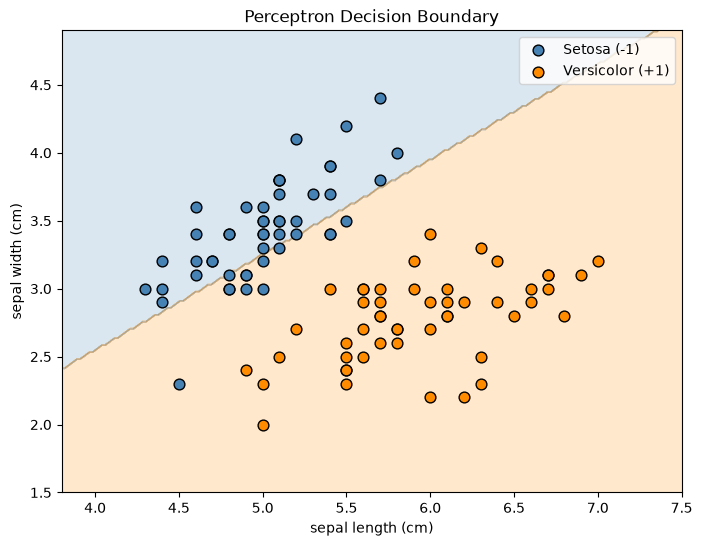

In [ ]:
# Plotting the line generated by the perceptron

plt.figure(figsize=(8, 6))

x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 200),
                     np.linspace(x1_min, x1_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2, colors=['steelblue', 'darkorange'])
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
            color='steelblue', label='Setosa (-1)', edgecolor='k', s=60)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='darkorange', label='Versicolor (+1)', edgecolor='k', s=60)

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.show()

Note that this boundary seems like the model is certainly doing something, however it is certainly not as good as it could be, especially considering that you can clearly linearly separate this data. The Perceptron model that I wrote defaults to 50 epochs or training the model 50 times. Lets see what happens when we up the epochs so the model trains for longer.

In [ ]:
# Generating a new perceptron with more training steps

model2 = Perceptron(epochs = 200)
model2.train(X, y)

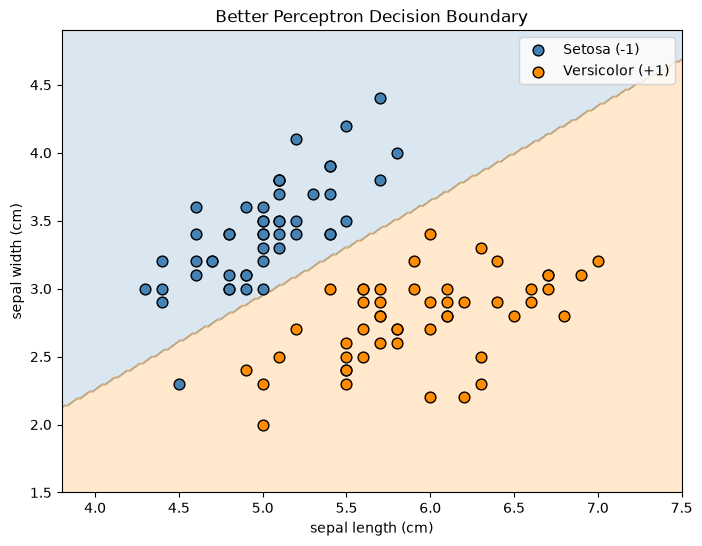

In [ ]:
# Plotting the new perceptron

plt.figure(figsize=(8, 6))

x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 200),
                     np.linspace(x1_min, x1_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model2.predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2, colors=['steelblue', 'darkorange'])
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
            color='steelblue', label='Setosa (-1)', edgecolor='k', s=60)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='darkorange', label='Versicolor (+1)', edgecolor='k', s=60)

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title('Better Perceptron Decision Boundary')
plt.legend()
plt.show()

As you can see, with more training, the Perceptron almost perfectly separates the data! Now we can look into how effectively these models actually predicted the data.

In [ ]:
# Here we are taking the percentage of data that was predicted correctly in both models

acc1 = np.mean(model.predict(X) == y)
acc2 = np.mean(model2.predict(X) == y)

print(f"Model 1 accuracy:  {acc1:.2f}")
print(f"Model 2 accuracy:  {acc2:.2f}")

Model 1 accuracy:  0.8700
Model 2 accuracy:  0.9900


As you can see, on this easily separable data, with a large number of epochs (or learning steps), the model achieves an accuracy of 99%. Additionally, as the boundary has been created pretty accurately on the training data, if we introduce a new point say (6.2, 2.5) we are able to predict the type of that flower.

In [ ]:
# Demonstrating predict method

if model2.predict([6.2, 2.5]) == 1:
    print("Versicolor")
else:
    print("Setosa")

Versicolor


If you consider where that point would be on the above graph, it would be right in the middle of the Versicolors and based on previous data, a human too would assume it is likely a Versicolor.